In [2]:
import xml.etree.ElementTree as ET
import numpy as np
from scipy.interpolate import interp1d
import xarray as xr
from tqdm import tqdm  # standard progress bar
import matplotlib.pyplot as plt
from lifetime_parser.parser import event_stream, read_first_n, file_properties
from lifetime_parser.events_filter.coincidence import file_coincidence_parser, event_coincidence_filter
from lifetime_parser.time_analysis import good_event, cfd_linear, read_lifetime, cfd_analog_time
from lifetime_parser.energy_analysis.baseline import baseline_estimation
from lifetime_parser.energy_analysis.pulse_height import pulse_height_3pts_parabolic, pulse_height_robust

In [4]:
# --------- CONFIG ---------
# note to take the data of the face to face detectors
bin_file = "./28.1.26CoANDCoincidence_trig0.065_65Events.lftmbin"
max_events = 10000
channels = file_properties(bin_file).channels
BINS_IN_WAVEFORM = 1024
# --------------------------

estimate energy treshold 

In [6]:
da = read_first_n(bin_file, max_events)

In [7]:
ch1_t, ch1_v = da['time'].sel(channel=[channels[0]]).values[0], da['voltage'].sel(channel=[channels[0]]).values[0]
ch2_t, ch2_v = da['time'].sel(channel=[channels[1]]).values[0], da['voltage'].sel(channel=[channels[1]]).values[0]

ch1_height = -pulse_height_robust(ch1_t, ch1_v)
ch2_height = -pulse_height_robust(ch2_t, ch2_v)

ch1_count, ch1_bins = np.histogram(ch1_height[np.isfinite(ch1_height)], bins=1024)
ch2_count, ch2_bins = np.histogram(ch2_height[np.isfinite(ch2_height)], bins=1024)

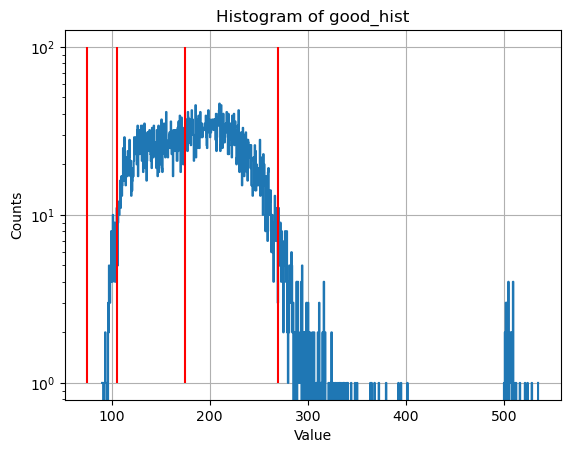

In [15]:
plt.step(ch1_bins[:-1], ch1_count, where='post')  # 'post' aligns steps correctly

plt.xlabel("Value")
plt.ylabel("Counts")
plt.title("Histogram of good_hist")
#plt.yscale('log')
#plt.xlim([4000,12000])
plt.grid()

ch1_511_lb = 75
ch1_511_ub = 105

ch1_1274_lb = 175
ch1_1274_ub = 270

plt.vlines(x=ch1_511_lb, ymax=100, ymin=1, color='red')
plt.vlines(x=ch1_511_ub, ymax=100, ymin=1, color='red')

plt.vlines(x=175, ymax=100, ymin=1, color='red')
plt.vlines(x=270, ymax=100, ymin=1, color='red')
plt.yscale('log')

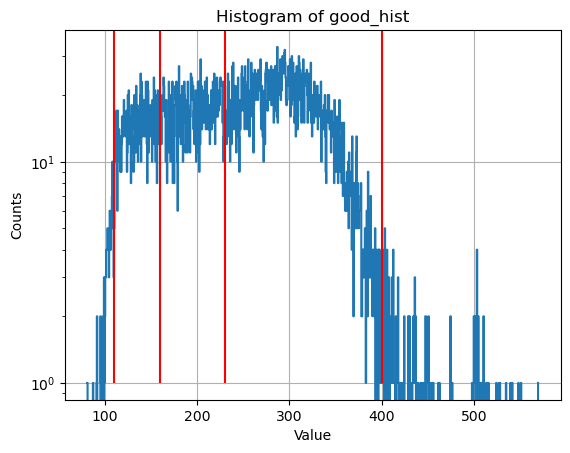

In [16]:
plt.step(ch2_bins[:-1], ch2_count, where='post')  # 'post' aligns steps correctly
plt.xlabel("Value")
plt.ylabel("Counts")
plt.title("Histogram of good_hist")
plt.yscale('log')
#plt.xlim([4000,12000])
plt.grid()

ch2_511_lb = 110
ch2_511_ub = 160


ch2_1274_lb = 230
ch2_1274_ub = 400

plt.vlines(x=ch2_511_lb, ymax=100, ymin=1, color='red')
plt.vlines(x=ch2_511_ub, ymax=100, ymin=1, color='red')

plt.vlines(x=ch2_1274_lb, ymax=100, ymin=1, color='red')
plt.vlines(x=ch2_1274_ub, ymax=100, ymin=1, color='red')

Read the lifetimes of the face to face data

In [10]:
lifetime = read_lifetime(bin_file,
                         channels=channels,
                         cfd_method="linear",
                         thresholds=(-65.0, -85.0),
                         cfd_fraction = 0.3, cfd_delay=1.4)

use the boundries from the spectrum

In [19]:
e1 = lifetime["energy_1"].values
e2 = lifetime["energy_2"].values
t1 = lifetime["time_1"].values
t2 = lifetime["time_2"].values

lb1_1274, ub1_1274 = -ch1_1274_lb, -ch1_1274_ub
lb1_511,  ub1_511  = -ch1_511_lb, -ch1_511_ub
lb2_1274, ub2_1274 = -ch2_1274_lb, -ch2_1274_ub
lb2_511,  ub2_511  = -ch2_511_lb, -ch2_511_ub

mask_1_2 = (
    (e1 < lb1_1274) & (e1 > ub1_1274) &
    (e2 < lb2_511)  & (e2 > ub2_511)
)

mask_2_1 = (
    (e2 < lb2_1274) & (e2 > ub2_1274) &
    (e1 < lb1_511)  & (e1 > ub1_511)
)

# one see first 1274
time_diff_1_2 = (t2 - t1)[mask_1_2]
# two see first 1274
time_diff_2_1 = (t2-t1)[mask_2_1]


In [20]:
bins = np.arange(-7.5, 7.5, 20/1000)

FWHM = 0.25999999999999446


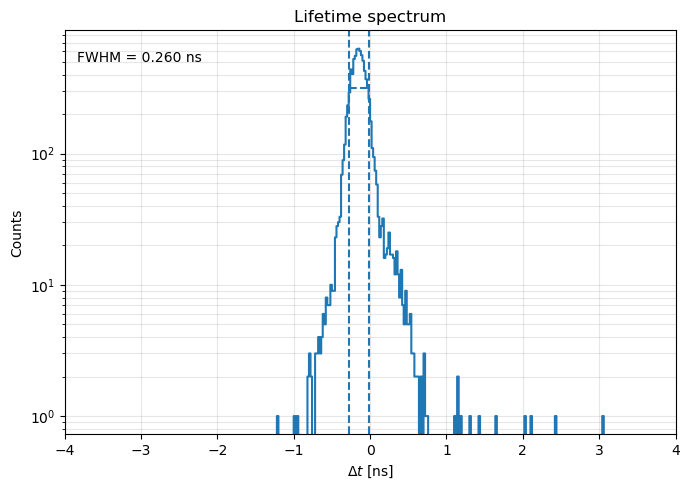

In [21]:
# Histogram (no plotting yet)
counts, edges = np.histogram(time_diff_1_2, bins=bins)

# Bin centers
centers = 0.5 * (edges[:-1] + edges[1:])

# Plot as step
plt.figure(figsize=(7, 5))
plt.step(centers, counts, where='mid')
plt.yscale("log")
plt.xlim([-4, 4])
plt.xlabel(r'$\Delta t$ [ns]')
plt.ylabel('Counts')
plt.title('Lifetime spectrum')
plt.grid(which='both', alpha=0.3)

# Maximum and half-maximum
imax = np.argmax(counts)
half_max = counts[imax] / 2

# Find left and right half-max crossings
left_idx = np.where(counts[:imax] <= half_max)[0]
right_idx = np.where(counts[imax:] <= half_max)[0]

if len(left_idx) > 0 and len(right_idx) > 0:
    i_left = left_idx[-1]
    i_right = imax + right_idx[0]
    fwhm = centers[i_right] - centers[i_left]

    # Draw FWHM markers
    plt.axvline(centers[i_left], linestyle='--')
    plt.axvline(centers[i_right], linestyle='--')
    plt.hlines(half_max, centers[i_left], centers[i_right], linestyles='--')

    plt.text(
        0.02, 0.95,
        f'FWHM = {fwhm:.3f} ns',
        transform=plt.gca().transAxes,
        verticalalignment='top'
    )
else:
    fwhm = np.nan

print("FWHM =", fwhm)

plt.tight_layout()
plt.show()
